# **All About SVM**


## What is SVM?
Support Vector Machine is a **supervised classification algorithm** that finds the **optimal hyperplane** separating two classes with the **maximum possible margin**.

> Unlike Logistic Regression which finds *any* boundary that separates classes,  
> SVM finds the *best* boundary — the one with the **widest gap** between classes.

---

## Why Do We Need It?
Many boundaries can separate two classes — SVM picks the one that is **farthest from both classes**, making it more robust and generalizable to unseen data.
```
Logistic Regression      SVM
  x x | o o             x x  ←margin→ | ←margin→  o o
  (any line)                     (maximum margin line)
```

---

## Where Is It Used?
- Image classification
- Text & spam classification
- Handwriting recognition
- Bioinformatics (cancer vs non-cancer)
- Face detection

---

## Key Concepts

### Hyperplane
The decision boundary that separates classes.
$$w \cdot x + b = 0$$
- In 2D → a line
- In 3D → a plane
- In nD → a hyperplane

### Margin
The distance between the hyperplane and the **nearest points** of each class.
$$\text{Margin} = \frac{2}{\|w\|}$$
SVM maximizes this margin → minimizing ‖w‖.

### Support Vectors
The **closest data points** to the hyperplane from each class.  
These are the only points that define and influence the boundary — all other points don't matter.
```
    x          support → x* | o* ← support
    x x                     |          o o
                        hyperplane
```

---

## How It Works (Mechanism)
```
Input → Linear Score → Hinge Loss Check → Update Weights → Predict via Sign
  X       w·x + b         y(w·x+b)≥1       gradient step     sign(w·x+b)
```

**1. Label Format**  
SVM requires labels as **-1 and +1** (not 0 and 1)
$$y \in \{-1, +1\}$$

**2. Decision Rule**
$$\hat{y} = \text{sign}(w \cdot x + b)$$

**3. Hinge Loss**  
Penalizes points that are misclassified or fall inside the margin:
$$\text{Loss} = \max(0, \, 1 - y_i(w \cdot x_i + b))$$
- Correctly classified & outside margin → Loss = 0
- Inside margin or misclassified → Loss > 0

**4. Objective — Minimize:**
$$J = \lambda\|w\|^2 + \frac{1}{m}\sum_{i=1}^{m} \max(0, 1 - y_i(w \cdot x_i + b))$$
$$\underbrace{\lambda\|w\|^2}_{\text{maximize margin}} + \underbrace{\text{hinge loss}}_{\text{minimize misclassification}}$$

**5. Gradient Update Rules**

If $y_i(w \cdot x_i + b) \geq 1$ → point is safe:
$$w \leftarrow w - \alpha(2\lambda w)$$

If $y_i(w \cdot x_i + b) < 1$ → point violates margin:
$$w \leftarrow w - \alpha(2\lambda w - x_i y_i)$$
$$b \leftarrow b - \alpha(-y_i)$$

---

## Hard Margin vs Soft Margin

| | Hard Margin | Soft Margin |
|---|---|---|
| Allows misclassification | No | Yes |
| Works when | Data is perfectly separable | Data has noise/overlap |
| Risk | Overfits noisy data | More generalizable |
| Controlled by | — | Regularization parameter C (or λ) |

> Real-world data is rarely perfectly separable → **Soft Margin SVM** is almost always used.

---

## The Kernel Trick
Linear SVM only works when data is **linearly separable**.  
For non-linear data, the **Kernel Trick** maps data into a higher dimension where it becomes separable — without actually computing the transformation.

| Kernel | Best For |
|---|---|
| Linear | Linearly separable data |
| RBF (Gaussian) | Non-linear, general purpose |
| Polynomial | Curved boundaries |
```
2D non-separable  →  Kernel  →  3D separable  →  hyperplane  →  project back to 2D
```

---

## Regularization Parameter (C / λ)

$$C = \frac{1}{\lambda}$$

| High C (low λ) | Low C (high λ) |
|---|---|
| Small margin | Large margin |
| Fits training data closely | More generalizable |
| Risk of overfitting | Risk of underfitting |

---

## Key Assumptions
- Works best when classes are **clearly separable**
- Sensitive to **feature scaling** — always normalize before training
- Labels must be **-1 and +1**
- Kernel choice matters for **non-linear** problems

---

## Advantages
| ✅ Pro | Reason |
|---|---|
| Maximum margin boundary | More robust than logistic regression |
| Works in high dimensions | Effective for text classification |
| Only support vectors matter | Memory efficient |
| Kernel trick | Handles non-linear data elegantly |
| Less sensitive to outliers | Margin-based, not probability-based |

---

## Problems & Limitations
| ❌ Problem | Explanation |
|---|---|
| Slow on large datasets | O(n²) to O(n³) training complexity |
| Feature scaling required | Unscaled features break the margin |
| Hard to interpret | No probability output by default |
| Kernel selection is tricky | Wrong kernel = poor performance |
| Binary by default | Needs One-vs-Rest for multiclass |

---

## SVM vs Logistic Regression vs Softmax

| | Logistic Regression | Softmax Regression | Linear SVM |
|---|---|---|---|
| Classes | 2 | 3+ | 2 (extendable) |
| Output | Probability | Probability per class | Raw score → sign |
| Loss | Binary Cross-Entropy | Categorical Cross-Entropy | Hinge Loss |
| Goal | Maximize likelihood | Maximize likelihood | Maximize margin |
| Outlier sensitivity | High | High | Low |
| Labels | 0, 1 | 0, 1, 2... | -1, +1 |

---

## The Big Picture
```
                ← margin →   ← margin →
    x   x   x*     |    o*   o   o   o
                    |
              w·x + b = 0
              (hyperplane)

  sign(w·x+b) < 0 → Class -1
  sign(w·x+b) > 0 → Class +1
```

SVM is one of the most theoretically elegant algorithms in ML — it doesn't just find *a* boundary, it finds the *optimal* one. With the Kernel Trick, it extends to non-linear problems, making it powerful across a wide range of real-world tasks.

# **Imports**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.svm import SVC
import seaborn as sns

# **Dataset Generation & Visualization**

In [2]:
# Dataset Generation (binary classification, consistent with earlier ones)
X, y = make_classification(
    n_samples=600, n_features=2, n_classes=2,
    n_informative=2, n_redundant=0,
    n_clusters_per_class=1, random_state=42
)

In [3]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

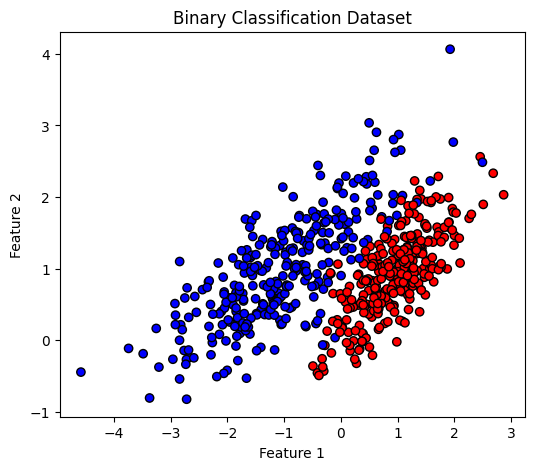

In [4]:
# Visualize dataset
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr', edgecolors='k')
plt.title("Binary Classification Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# **Custom SVM Model**

In [5]:
class SimpleLinearSVM:
    def __init__(self, learning_rate=0.001, regularization_strength=0.01, num_iterations=1000):
        self.learning_rate = learning_rate
        self.regularization_strength = regularization_strength
        self.num_iterations = num_iterations
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        num_samples, num_features = X.shape

        # SVM requires labels in {-1, +1} format
        y_converted = np.where(y <= 0, -1, 1)

        self.weights = np.zeros(num_features)
        self.bias = 0

        for i in range(self.num_iterations):
            for index, x_example in enumerate(X):
                # Hinge loss condition: correctly classified AND outside the margin
                margin_condition = y_converted[index] * (np.dot(x_example, self.weights) + self.bias) >= 1

                if margin_condition:
                    # Only apply L2 regularization — no misclassification to fix
                    self.weights -= self.learning_rate * (2 * self.regularization_strength * self.weights)
                else:
                    # Misclassified or inside margin — update both weights and bias
                    self.weights -= self.learning_rate * (2 * self.regularization_strength * self.weights - np.dot(x_example, y_converted[index]))
                    self.bias -= self.learning_rate * y_converted[index]

    def predict(self, X):
        score = np.dot(X, self.weights) + self.bias
        return np.sign(score)  # +1 or -1 based on which side of the hyperplane

# **Explanation of Custom Model**

## Example Dataset
| Hours Studied | Hours Slept | Result |
|---|---|---|
| 1 | 8 | Fail (-1) |
| 2 | 7 | Fail (-1) |
| 6 | 5 | Pass (+1) |
| 8 | 4 | Pass (+1) |

> SVM requires labels as **-1 and +1**, not 0 and 1.

---

## Step 1: Convert Labels & Initialize
```
y_original  = [0, 0, 1, 1]
y_converted = [-1, -1, +1, +1]   ← np.where(y <= 0, -1, 1)

weights = [0, 0]   ← one per feature
bias    = 0
```

---

## Step 2: The Core Idea — Margin & Hyperplane

SVM finds a **decision boundary (hyperplane)** that separates classes with the **maximum margin**.
```
         Fail (-1)  |  margin  |  Pass (+1)
                    |          |
          x x       | ←  2/‖w‖ →|      o o
                    |          |
                 hyperplane
              w·x + b = 0
```

- Points **outside the margin** and correctly classified → only regularize
- Points **inside the margin or misclassified** → fix weights AND bias

---

## Step 3: Hinge Loss Condition (Per Sample)

For each sample, check:
$$y_i \cdot (w \cdot x_i + b) \geq 1$$
```
Sample 1: y=-1, x=[1,8]
  score = (-1) * (0·1 + 0·8 + 0) = 0
  0 >= 1 ? → NO  → misclassified / inside margin → update weights & bias

Sample 3: y=+1, x=[6,5]
  score = (+1) * (0·6 + 0·5 + 0) = 0
  0 >= 1 ? → NO  → misclassified / inside margin → update weights & bias
```
> All zeros initially, so every sample triggers the misclassification update in iteration 1.

---

## Step 4: Weight & Bias Update Rules

**Case 1 — Correctly classified & outside margin:**
```
weights -= lr * (2 * λ * weights)    ← only L2 regularization, keep weights small
bias stays unchanged
```

**Case 2 — Misclassified or inside margin:**
```
weights -= lr * (2 * λ * weights  -  x_i * y_i)
                 └─ regularization ┘  └─ hinge ┘
bias    -= lr * y_i
```

**One manual update for Sample 1** (y=-1, x=[1,8], lr=0.001, λ=0.01):
```
weights -= 0.001 * (2*0.01*[0,0]  -  [1,8]*(-1))
         = 0.001 * (  [0,0]       +  [1,8] )
         = 0.001 * [1, 8]
weights  = [-0.001, -0.008]

bias    -= 0.001 * (-1) = +0.001
```

---

## Step 5: After 1000 Iterations
```
weights converge → a vector perpendicular to the decision boundary
bias    converges → shifts the boundary to correctly separate classes

predict([1, 8]):  score = w·x + b < 0 → sign → -1 (Fail) ✓
predict([2, 7]):  score = w·x + b < 0 → sign → -1 (Fail) ✓
predict([6, 5]):  score = w·x + b > 0 → sign → +1 (Pass) ✓
predict([8, 4]):  score = w·x + b > 0 → sign → +1 (Pass) ✓
```

---


## SVM vs Logistic Regression

| | Logistic Regression | Linear SVM |
|---|---|---|
| Output | Probability (0 to 1) | Raw score → sign (+1/-1) |
| Decision | prob ≥ 0.5 | sign(w·x + b) |
| Loss | Cross-Entropy | Hinge Loss |
| Goal | Maximize likelihood | Maximize margin between classes |
| Sensitive to outliers | Yes | Less so (margin-based) |
| Labels | 0 and 1 | -1 and +1 |

# **Evaluation of Custom Model**

Scratch Linear SVM Accuracy: 0.4777777777777778


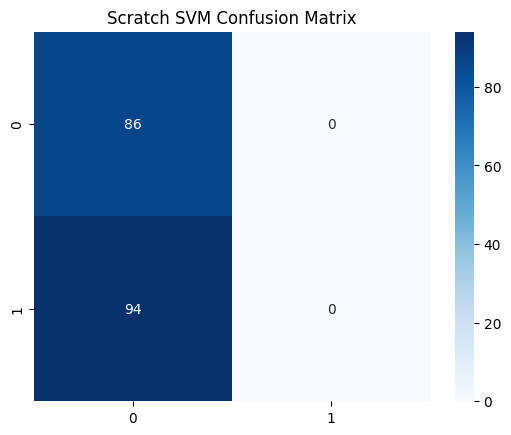

In [ ]:
svm_scratch = SimpleLinearSVM(learning_rate=0.001,regularization_strength=0.01 , num_iterations=1500)
svm_scratch.fit(X_train, y_train)

y_pred_scratch = svm_scratch.predict(X_test)
y_pred_scratch = np.where(y_pred_scratch == -1, 0, 1)  # convert back {-1,1} → {0,1}

print("Scratch Linear SVM Accuracy:", accuracy_score(y_test, y_pred_scratch))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_scratch)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Scratch SVM Confusion Matrix")
plt.show()


# **Sklearn's SVM Model**

Sklearn Linear SVM Accuracy: 0.9611111111111111


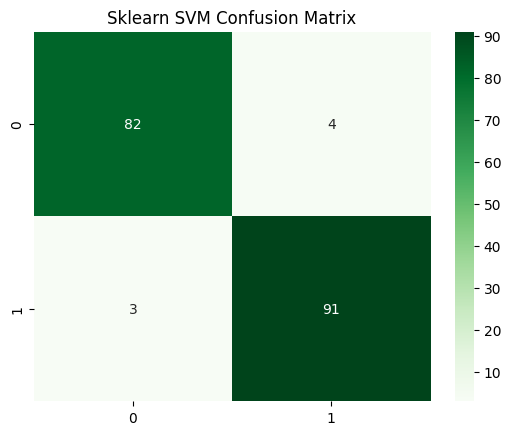

In [ ]:
svm_sklearn = SVC(kernel="linear")
svm_sklearn.fit(X_train, y_train)

y_pred_sklearn = svm_sklearn.predict(X_test)

print("Sklearn Linear SVM Accuracy:", accuracy_score(y_test, y_pred_sklearn))

cm = confusion_matrix(y_test, y_pred_sklearn)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Sklearn SVM Confusion Matrix")
plt.show()

# **Comparision Between Models**

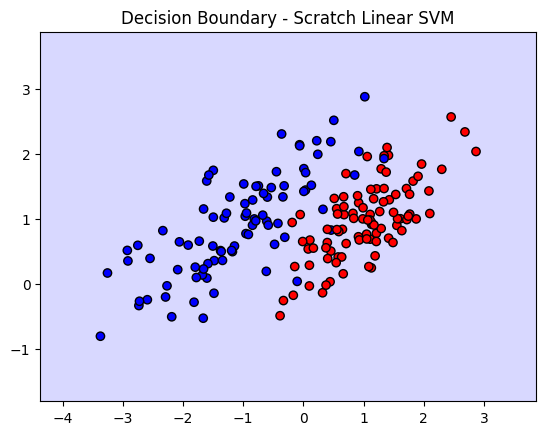

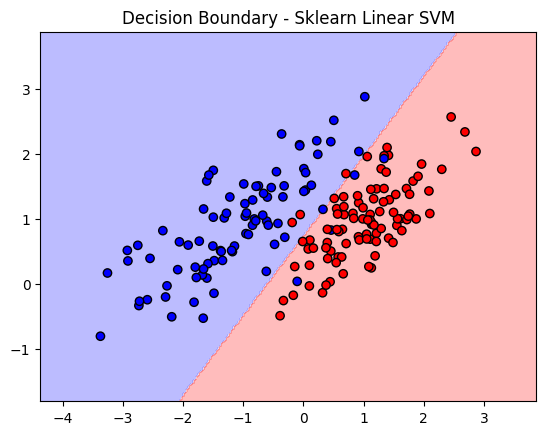

In [ ]:
def plot_decision_boundary(X, y, model, title):
    x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
    y_min, y_max = X[:, 1].min()-1, X[:, 1].max()+1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))

    grid = np.c_[xx.ravel(), yy.ravel()]
    y_pred = model.predict(grid)
    if isinstance(y_pred[0], np.float64):  # scratch model returns {-1,1}
        y_pred = np.where(y_pred==-1,0,1)

    y_pred = y_pred.reshape(xx.shape)

    plt.contourf(xx, yy, y_pred, alpha=0.3, cmap='bwr')
    plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr', edgecolors='k')
    plt.title(title)
    plt.show()

# Scratch SVM
plot_decision_boundary(X_test, y_test, svm_scratch, "Decision Boundary - Scratch Linear SVM")

# Sklearn SVM
plot_decision_boundary(X_test, y_test, svm_sklearn, "Decision Boundary - Sklearn Linear SVM")
